<a href="https://colab.research.google.com/github/vennelanalajam/myproject/blob/main/cust_churn_pred.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Telecom Customer Churn Prediction - End-to-End Data Science Project

# Step 1 : Business Understanding

The telecom industry is highly competitive, and customer retention is one of the biggest challenges faced by telecom companies.

No-Churn Telecom wants to use Machine Learning techniques to identify customers who are likely to discontinue their services.

The company aims to:



- Understand the factors influencing customer churn
- predict whether a customer will churn or not
- Generate churn risk scores
- Improve customer retention strategies
- Support business decision-making

This project focuses on building an intelligent churn prediction system using Machine Learning algorithms.



# Step 2: Problem Statement

Customer churn refers to customers leaving a telecom service provider and switching to competitors.

Due to increasing competition in the telecom sector, No-Churn Telecom is experiencing a churn rate higher than 10%.

The company wants to build a predictive Machine Learning Models that can:

- predict customer churn
- Identify high-risk customers
- Help the retention team take preventive actions


# Step 3: Project Objectives

The major objectives of this project are:

- Analyze customer behavior and usage patterns
- Identify important variables affecting churn
- Build a machine learning model for churn prediction
- Generate churn probability scores
- Help the business improve customer retention strategies

# Step 4 : Import Libraries

In this step, necessary python libraries are imported for:

- Data manipulation
- Data visualization
- Machine Learning
- Model evaluation
- Database connection
- Data preprocessing

In [2]:
!pip install pymysql
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import pymysql

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score
from imblearn.over_sampling import SMOTE

import warnings
warnings.filterwarnings("ignore")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.4/45.4 kB 1.7 MB/s eta 0:00:00


# Step 5 : Database Connection

The dataset is stored inside a MySQL database.

using the pymysql library, a connection is established between python and the SQL database.

The telecom churn dataset is extracted using SQL queries and loaded into a Pandas DataFrame for further analysis.

In [3]:
connection = pymysql.connect(
    host = '18.136.157.135',
    user = 'dm_team3',
    password = 'DM!$!Team!27@9!20&',
    database = 'project_telecom'
)

query = "SELECT * FROM telecom_churn_data"

df = pd.read_sql(query, connection)

# Step 6: Data Understanding

Before performing analysis, it is important to understand the structure of  the dataset.

This step helps to:   

- Understand data types
- Identify numerical and categorical variables
- Detect missing values
- Understand dataset dimensions
- Get statisticals summaries

# View Dataset

The first few records are displayed to understand the structure and contents of the dataset.

In [4]:
df.head()

,customer_id,telecom_partner,gender,age,state,city,pincode,date_of_registration,num_dependents,estimated_salary,calls_made,sms_sent,data_used,churn
0,1,Reliance Jio,F,25,Karnataka,Kolkata,755597,2020-01-01,4,124962,44,45,-361,0
1,2,Reliance Jio,F,55,Mizoram,Mumbai,125926,2020-01-01,2,130556,62,39,5973,0
2,3,Vodafone,F,57,Arunachal Pradesh,Delhi,423976,2020-01-01,0,148828,49,24,193,1
3,4,BSNL,M,46,Tamil Nadu,Kolkata,522841,2020-01-01,1,38722,80,25,9377,1
4,5,BSNL,F,26,Tripura,Delhi,740247,2020-01-01,2,55098,78,15,1393,0


# Dataset shape

This step helps identify:

- Number of rows
- Number of columns

In [5]:
df.shape

(243553, 14)

# Dataset Information

This function provides:

- columns names
- Data types
- Non-null values
- memory usage

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 243553 entries, 0 to 243552
Data columns (total 14 columns):
 #   Column                Non-Null Count   Dtype 
---  ------                --------------   ----- 
 0   customer_id           243553 non-null  int64 
 1   telecom_partner       243553 non-null  object
 2   gender                243553 non-null  object
 3   age                   243553 non-null  int64 
 4   state                 243553 non-null  object
 5   city                  243553 non-null  object
 6   pincode               243553 non-null  int64 
 7   date_of_registration  243553 non-null  object
 8   num_dependents        243553 non-null  int64 
 9   estimated_salary      243553 non-null  int64 
 10  calls_made            243553 non-null  int64 
 11  sms_sent              243553 non-null  int64 
 12  data_used             243553 non-null  int64 
 13  churn                 243553 non-null  int64 
dtypes: int64(9), object(5)
memory usage: 26.0+ MB


# Statistical Summary

Statistical measures such as:

- Mean
- Median
- Standard deviation
- Minimum value
- Maximum value

are analyzed for numerical features.

In [7]:
df.describe()

,customer_id,age,pincode,num_dependents,estimated_salary,calls_made,sms_sent,data_used,churn
count,243553.000000,243553.000000,243553.000000,243553.000000,243553.000000,243553.000000,243553.000000,243553.000000,243553.000000
mean,121777.000000,46.077609,549501.270541,1.997500,85021.137839,49.010548,23.945404,4993.186025,0.200478
std,70307.839393,16.444029,259808.860574,1.414941,37508.963233,29.453556,14.733575,2942.019547,0.400359
min,1.000000,18.000000,100006.000000,0.000000,20000.000000,-10.000000,-5.000000,-987.000000,0.000000
25%,60889.000000,32.000000,324586.000000,1.000000,52585.000000,24.000000,11.000000,2490.000000,0.000000
50%,121777.000000,46.000000,548112.000000,2.000000,84990.000000,49.000000,24.000000,4987.000000,0.000000
75%,182665.000000,60.000000,774994.000000,3.000000,117488.000000,74.000000,36.000000,7493.000000,0.000000
max,243553.000000,74.000000,999987.000000,4.000000,149999.000000,108.000000,53.000000,10991.000000,1.000000


# Step 7: Exploratory Data Analysis(EDA)

EDA is performed to discover hidden patterns, trends, and relationships within the data.

The major goals of EDA are:

- Understand customer behavior
- Analyze churn distribution
- Identify influential variables
- Detect outliers
- Understand feature relationships

In [8]:
# Missing value analysis
df.isnull().sum()

,0
customer_id,0
telecom_partner,0
gender,0
age,0
state,0
city,0
pincode,0
date_of_registration,0
num_dependents,0
estimated_salary,0


In [9]:
# Duplicate Records
df.duplicated().sum()

np.int64(0)

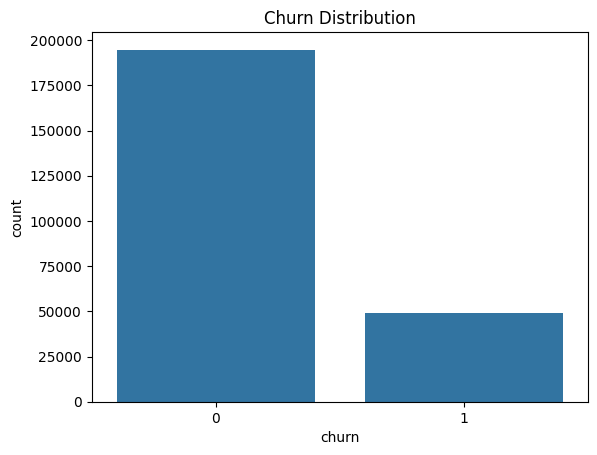

In [13]:
# Churn Distribution

sns.countplot(x = 'churn', data=df)
plt.title("Churn Distribution")
plt.show()

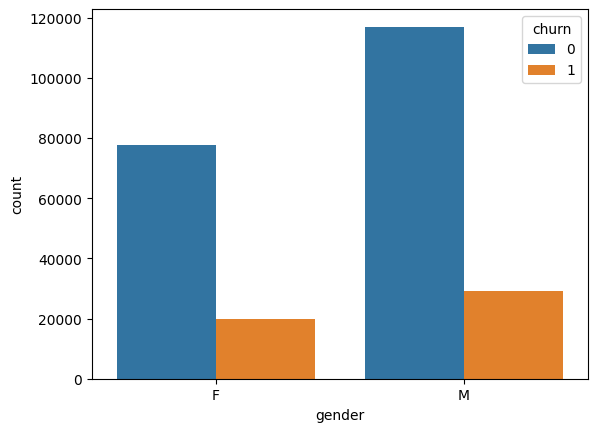

In [21]:
# Gender vs Churn

sns.countplot(x = 'gender', hue ='churn', data=df)
plt.show()

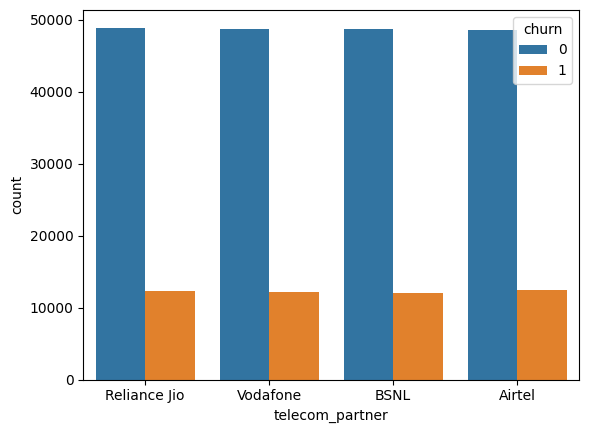

In [22]:
# Telecom Partner vs Churn

sns.countplot(x = 'telecom_partner',hue = 'churn', data=df)
plt.show()

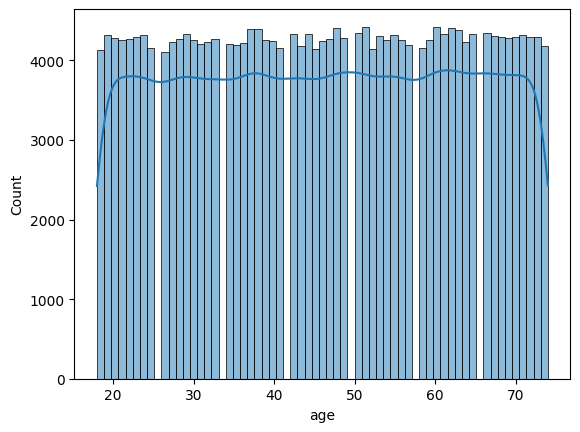

In [24]:
# Age Distribution

sns.histplot(df['age'], kde=True)
plt.show()

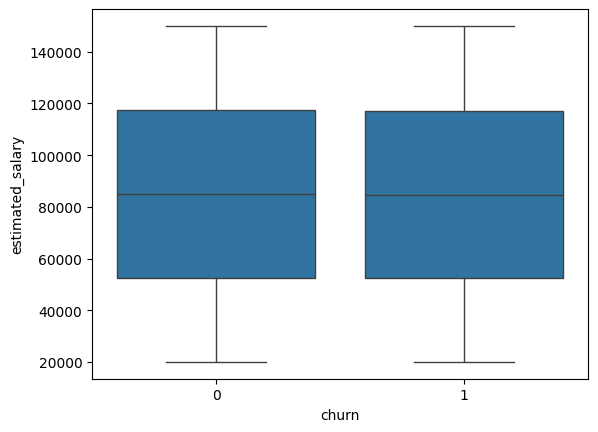

In [26]:
# Salary vs Churn
sns.boxplot( x = 'churn',y = 'estimated_salary', data=df)
plt.show()

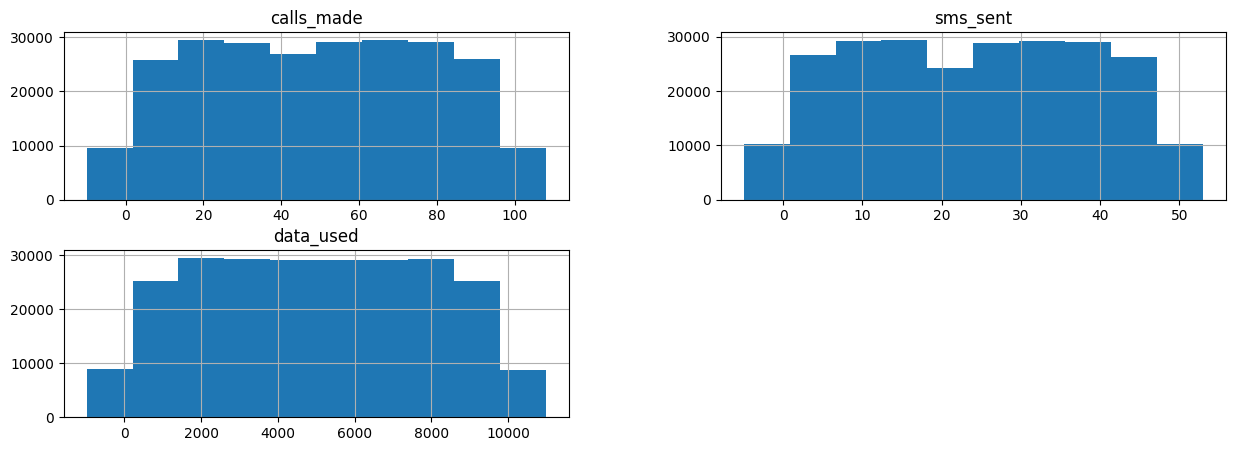

In [27]:
# Usage Feature Analysis
usage_cols = ['calls_made','sms_sent','data_used']
df[usage_cols].hist(figsize=(15,5))
plt.show()

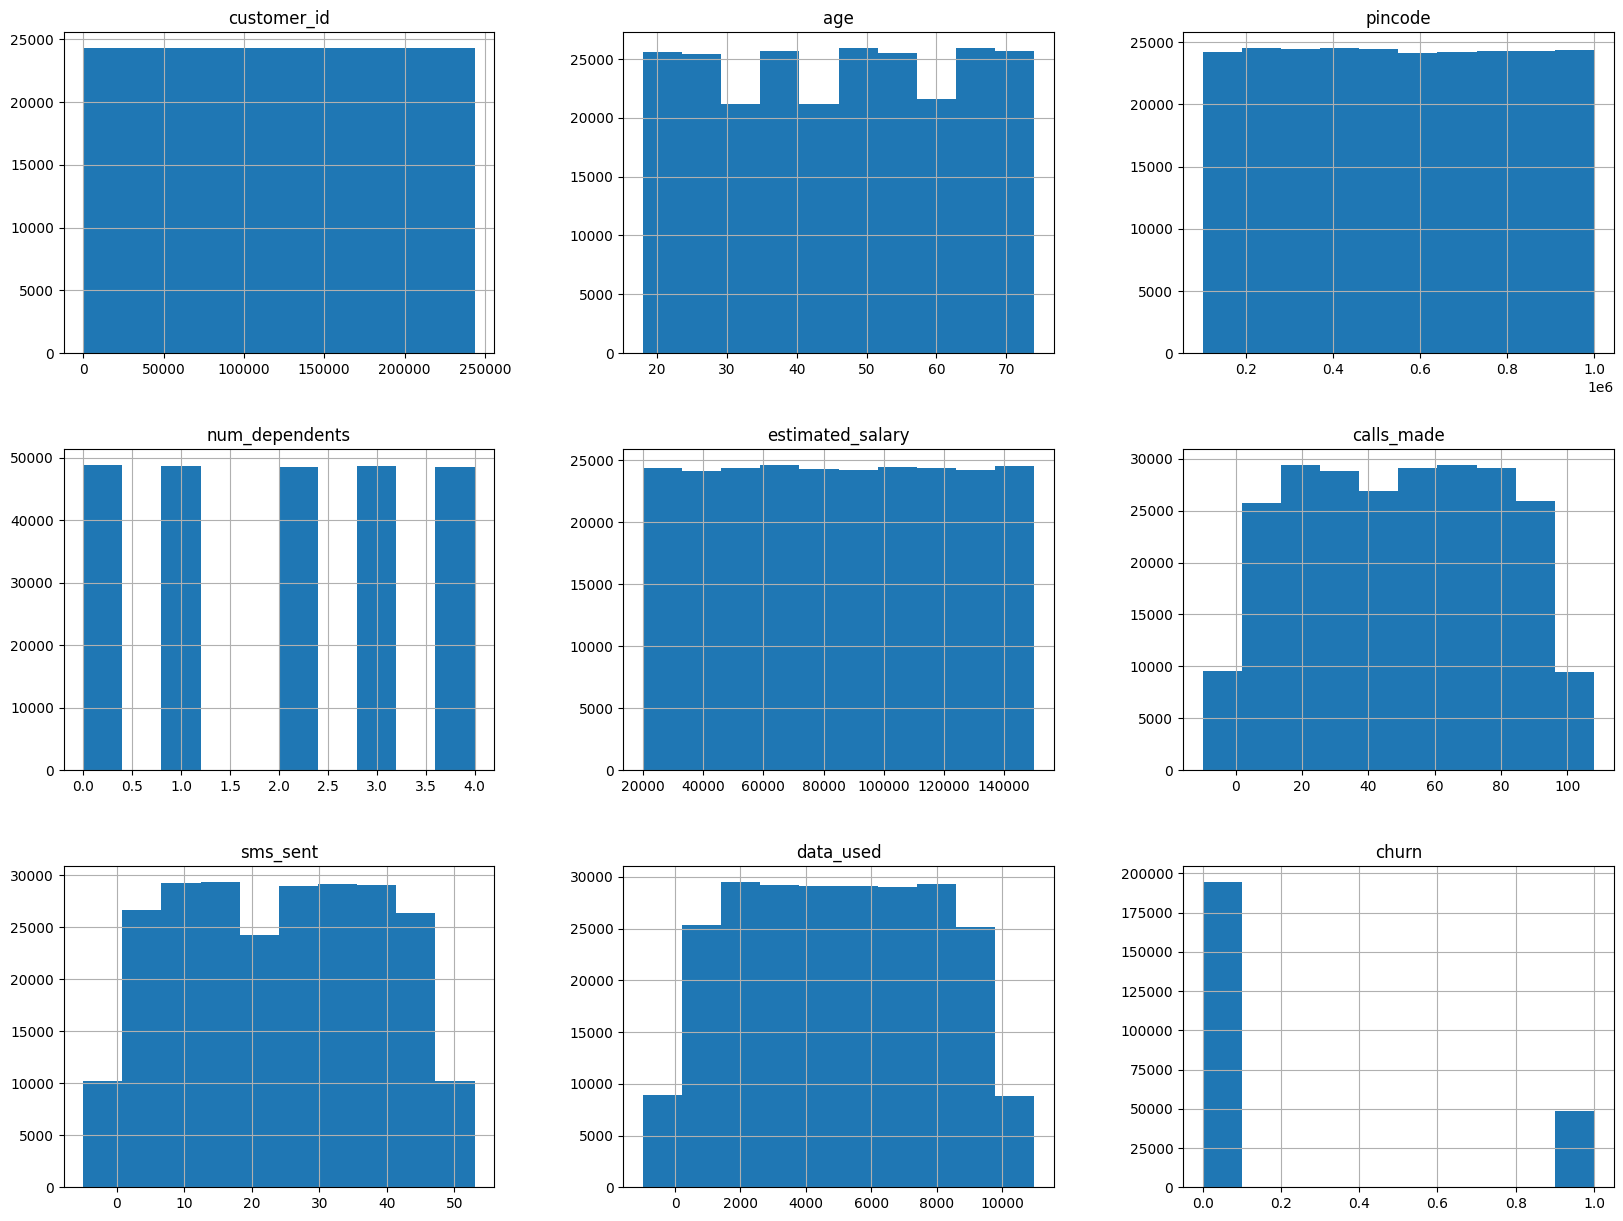

In [16]:
# Numerical Feature Distribution

df.hist(figsize=(20,15))
plt.show()

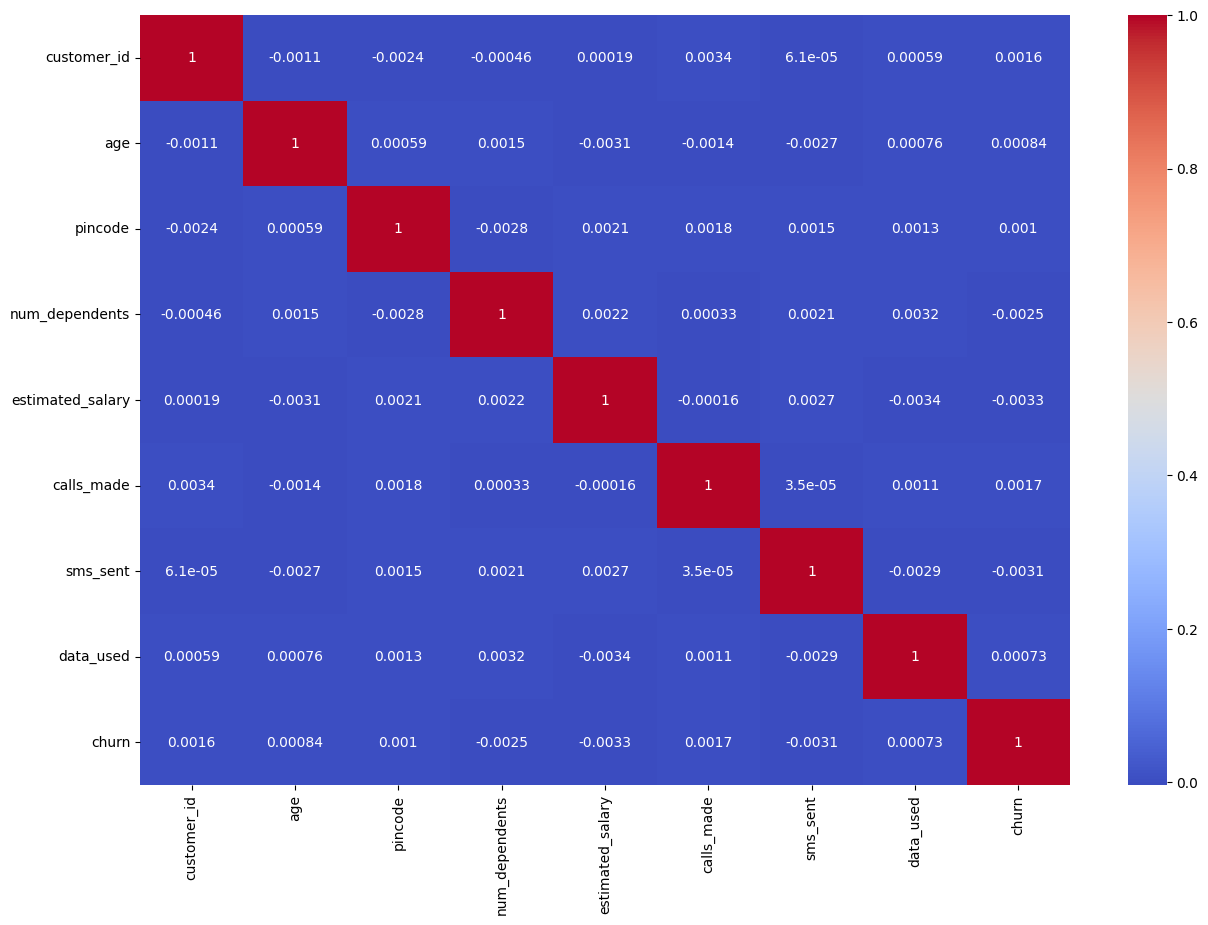

In [17]:
# Correlation Heatmap
plt.figure(figsize=(15,10))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.show()

# Step 8: Data Cleaning

Data cleaning improves dataset quality and model performance.

This includes:
- removing irrelevant columns
- handling missing values
- removing duplicates
- treating outliers

In [28]:
# Remove Irrelevant Columns
df.drop('customer_id', axis=1, inplace=True)

In [29]:
df.head()

,telecom_partner,gender,age,state,city,pincode,date_of_registration,num_dependents,estimated_salary,calls_made,sms_sent,data_used,churn
0,Reliance Jio,F,25,Karnataka,Kolkata,755597,2020-01-01,4,124962,44,45,-361,0
1,Reliance Jio,F,55,Mizoram,Mumbai,125926,2020-01-01,2,130556,62,39,5973,0
2,Vodafone,F,57,Arunachal Pradesh,Delhi,423976,2020-01-01,0,148828,49,24,193,1
3,BSNL,M,46,Tamil Nadu,Kolkata,522841,2020-01-01,1,38722,80,25,9377,1
4,BSNL,F,26,Tripura,Delhi,740247,2020-01-01,2,55098,78,15,1393,0


In [30]:
# Convert Date Column
# Date Feature Engineering

# The registration date is converted into datetime format for extracting useful features.

df['date_of_registration'] = pd.to_datetime(df['date_of_registration'])

In [31]:
df.head()

,telecom_partner,gender,age,state,city,pincode,date_of_registration,num_dependents,estimated_salary,calls_made,sms_sent,data_used,churn
0,Reliance Jio,F,25,Karnataka,Kolkata,755597,2020-01-01,4,124962,44,45,-361,0
1,Reliance Jio,F,55,Mizoram,Mumbai,125926,2020-01-01,2,130556,62,39,5973,0
2,Vodafone,F,57,Arunachal Pradesh,Delhi,423976,2020-01-01,0,148828,49,24,193,1
3,BSNL,M,46,Tamil Nadu,Kolkata,522841,2020-01-01,1,38722,80,25,9377,1
4,BSNL,F,26,Tripura,Delhi,740247,2020-01-01,2,55098,78,15,1393,0


In [32]:
# Extract Registration Features

df['registration_year'] = \
df["date_of_registration"].dt.year

df['registration_month']= \
df["date_of_registration"].dt.month

In [33]:
df.head()

,telecom_partner,gender,age,state,city,pincode,date_of_registration,num_dependents,estimated_salary,calls_made,sms_sent,data_used,churn,registration_year,registration_month
0,Reliance Jio,F,25,Karnataka,Kolkata,755597,2020-01-01,4,124962,44,45,-361,0,2020,1
1,Reliance Jio,F,55,Mizoram,Mumbai,125926,2020-01-01,2,130556,62,39,5973,0,2020,1
2,Vodafone,F,57,Arunachal Pradesh,Delhi,423976,2020-01-01,0,148828,49,24,193,1,2020,1
3,BSNL,M,46,Tamil Nadu,Kolkata,522841,2020-01-01,1,38722,80,25,9377,1,2020,1
4,BSNL,F,26,Tripura,Delhi,740247,2020-01-01,2,55098,78,15,1393,0,2020,1


In [34]:
# Drop Original Date Column
df.drop('date_of_registration',axis =1, inplace = True)

In [35]:
df.head()

,telecom_partner,gender,age,state,city,pincode,num_dependents,estimated_salary,calls_made,sms_sent,data_used,churn,registration_year,registration_month
0,Reliance Jio,F,25,Karnataka,Kolkata,755597,4,124962,44,45,-361,0,2020,1
1,Reliance Jio,F,55,Mizoram,Mumbai,125926,2,130556,62,39,5973,0,2020,1
2,Vodafone,F,57,Arunachal Pradesh,Delhi,423976,0,148828,49,24,193,1,2020,1
3,BSNL,M,46,Tamil Nadu,Kolkata,522841,1,38722,80,25,9377,1,2020,1
4,BSNL,F,26,Tripura,Delhi,740247,2,55098,78,15,1393,0,2020,1


# Step 9: Feature Engineering


New meaningful features are created from existing telecom usage variables to improve prediction performance.

In [36]:
# Total usage feature
df['total_usage']  = (df['calls_made'] + df['sms_sent'] + df['data_used'])

In [37]:
# usage per dependent
df['usage_per_dependent'] = (df['total_usage'] / (df['num_dependents'] + 1))

# Step 10: Encoding Categorical Variables

Machine Learning algorithms require numerical inputs.

Categorical variables are converted into numerical format using Label Encoding.

In [38]:
le = LabelEncoder()

cat_cols = ['telecom_partner','gender','state','city']
for col in cat_cols:
  df[col] = le.fit_transform(df[col])

In [39]:
df.head()

,telecom_partner,gender,age,state,city,pincode,num_dependents,estimated_salary,calls_made,sms_sent,data_used,churn,registration_year,registration_month,total_usage,usage_per_dependent
0,2,0,25,10,4,755597,4,124962,44,45,-361,0,2020,1,-272,-54.400000
1,2,0,55,16,5,125926,2,130556,62,39,5973,0,2020,1,6074,2024.666667
2,3,0,57,1,2,423976,0,148828,49,24,193,1,2020,1,266,266.000000
3,1,1,46,22,4,522841,1,38722,80,25,9377,1,2020,1,9482,4741.000000
4,1,0,26,24,2,740247,2,55098,78,15,1393,0,2020,1,1486,495.333333


# Step 11: Define Features and Target


The dataset is divided into:
- independent variables (X)
- target variable (y)

Target Variable:
- churn

In [40]:
x = df.drop('churn', axis = 1)
y = df['churn']

# Step 12: Train-Test-Split

In [42]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2, random_state=42)

# Step 13: Feature Scaling
# Feature Scaling

Scaling standardizes feature values into a common range.

Scaling is important for algorithms such as:
- Logistic Regression
- SVM
- KNN

In [43]:
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

# Step 14: Handle Imbalanced Data
# Handling Imbalanced Data

SMOTE is used to balance the dataset by generating synthetic samples for minority churn classes.


In [44]:
smote = SMOTE(random_state=42)

x_train_smote, y_train_smote = smote.fit_resample(x_train_scaled, y_train)

# Step 15: Model Building

# Model Building

Multiple Machine Learning algorithms are trained and evaluated to identify the best-performing churn prediction model.

In [45]:
# LogisticRegression
lr = LogisticRegression()
lr.fit(x_train_smote, y_train_smote)
lr_pred = lr.predict(x_test_scaled)

In [46]:
# Random Forest
# Random Forest Classifier

# Random Forest combines multiple decision trees to improve prediction accuracy and reduce overfitting.
rf = RandomForestClassifier()

rf.fit(x_train_smote, y_train_smote)

rf_pred = rf.predict(x_test_scaled)

# Step 16 : Model Evaluation
# Model Evaluation

Model performance is evaluated using:
- Accuracy
- Precision
- Recall
- F1-score
- ROC-AUC score

In [48]:
# Accuracy Score
print(accuracy_score(y_test, lr_pred))
print(accuracy_score(y_test, rf_pred))


0.5060253330869824
0.7977664182628154


[[19731 19197]
 [ 4865  4918]]
[[38848    80]
 [ 9771    12]]


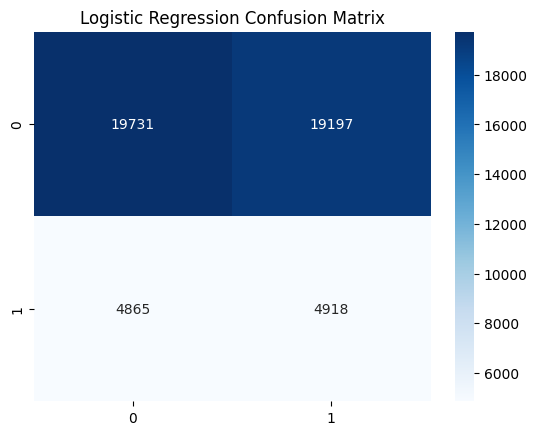

In [50]:
# Confusion Matrix
print(confusion_matrix(y_test, lr_pred))
print(confusion_matrix(y_test, rf_pred))

cm_lr = confusion_matrix(y_test,lr_pred)
cm_rf = confusion_matrix(y_test,rf_pred)

sns.heatmap(cm_lr, annot=True, cmap='Blues', fmt='g')
plt.title('Logistic Regression Confusion Matrix')
plt.show()

In [52]:
# Classification Report
print("LinearRegression")
print(classification_report(y_test, lr_pred))
print("Random_Forest")
print(classification_report(y_test, rf_pred))

LinearRegression
              precision    recall  f1-score   support

           0       0.80      0.51      0.62     38928
           1       0.20      0.50      0.29      9783

    accuracy                           0.51     48711
   macro avg       0.50      0.50      0.46     48711
weighted avg       0.68      0.51      0.55     48711

Random_Forest
              precision    recall  f1-score   support

           0       0.80      1.00      0.89     38928
           1       0.13      0.00      0.00      9783

    accuracy                           0.80     48711
   macro avg       0.46      0.50      0.44     48711
weighted avg       0.66      0.80      0.71     48711



# Step 17: Feature Importance
# Feature Importance

Feature importance identifies the variables that most influence churn prediction.

In [54]:
importance = pd.DataFrame({
    'Feature': x.columns,
    'Importance': rf.feature_importances_
})

importance.sort_values(
    by='Importance',
    ascending=False
)

,Feature,Importance
4,city,0.118867
12,registration_month,0.101275
6,num_dependents,0.086228
0,telecom_partner,0.081362
3,state,0.066078
11,registration_year,0.065485
7,estimated_salary,0.063417
5,pincode,0.063107
2,age,0.063037
9,sms_sent,0.060265


# Step 18: Churn Risk Score
# Churn Risk Score

The probability output of the model is used to generate churn risk scores for customers.


In [57]:
risk_score = rf.predict_proba(
    x_test_scaled
)[:,1]
risk_score

array([0.32, 0.22, 0.35, ..., 0.14, 0.22, 0.17])

# Step 19: Business Recommendation
# Business Recommendations

Based on churn analysis, the company can:

- target high-risk customers
- improve customer engagement
- offer personalized retention plans
- improve telecom service quality
- optimize customer support

# Step 20: Conclusion
# Conclusion

This project successfully developed a Machine Learning-based telecom churn prediction system.

The system helps:
- predict customer churn
- identify high-risk customers
- understand customer behavior
- support retention strategies

This solution can significantly reduce customer attrition and improve business profitability.
